In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split


In [2]:
df=pd.read_csv("bike_knnreg.csv")
df

,name,selling_price,year,seller_type,owner,km_driven,ex_showroom_price
0,Royal Enfield Classic 350,175000,2019,Individual,1st owner,350,NaN
1,Honda Dio,45000,2017,Individual,1st owner,5650,NaN
2,Royal Enfield Classic Gunmetal Grey,150000,2018,Individual,1st owner,12000,148114.0
3,Yamaha Fazer FI V 2.0 [2016-2018],65000,2015,Individual,1st owner,23000,89643.0
4,Yamaha SZ [2013-2014],20000,2011,Individual,2nd owner,21000,NaN
...,...,...,...,...,...,...,...
1056,Activa 3g,17000,2010,Individual,1st owner,500000,52000.0
1057,Honda CB twister,16000,2012,Individual,1st owner,33000,51000.0
1058,Bajaj Discover 125,15000,2013,Individual,2nd owner,35000,57000.0
1059,Honda CB Shine,12000,2009,Individual,1st owner,53000,58000.0


<Axes: >

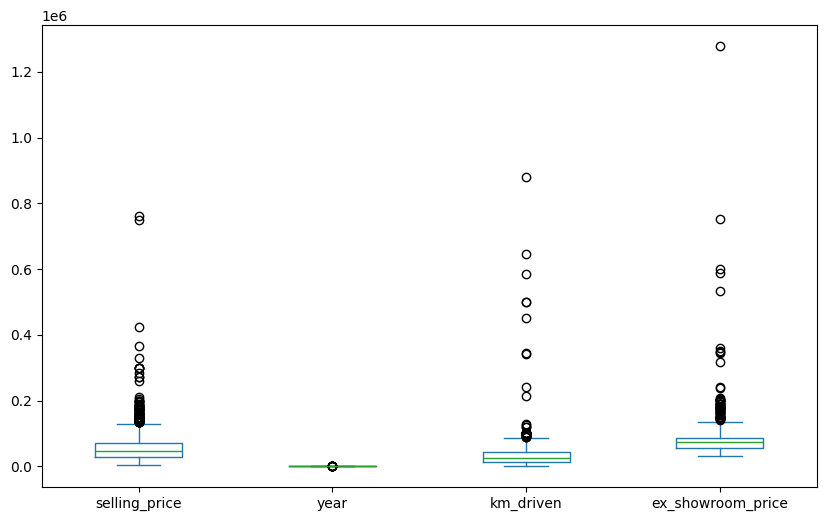

In [11]:
df.plot(kind="box", figsize=(10, 6),layout=(2, 3))

<Axes: >

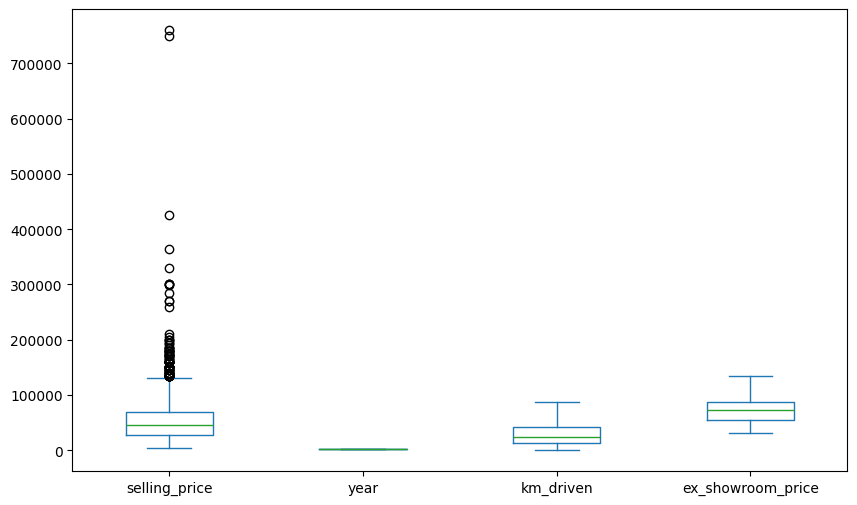

In [12]:
def iqr(col):
    q1=df[col].quantile(0.25)
    q3=df[col].quantile(0.75)
    iqr=q3-q1
    lower_bound=q1-1.5*iqr
    upper_bound=q3+1.5*iqr
    df[col]=df[col].clip(lower_bound, upper_bound)
iqr("year")
iqr("km_driven")
iqr("ex_showroom_price")
df.plot(kind="box", figsize=(10, 6),layout=(2, 3))

In [13]:
df.isnull().sum()

name                   0
selling_price          0
year                   0
seller_type            0
owner                  0
km_driven              0
ex_showroom_price    435
dtype: int64

<Axes: xlabel='ex_showroom_price', ylabel='Count'>

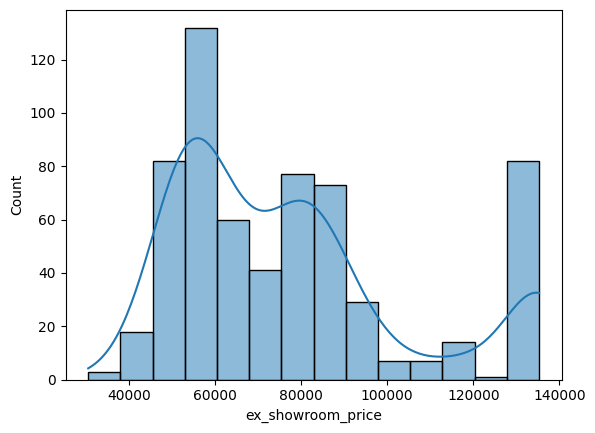

In [14]:
sns.histplot(df["ex_showroom_price"], kde=True)

In [15]:
df["ex_showroom_price"]=df["ex_showroom_price"].fillna(df["ex_showroom_price"].median())
df.isnull().sum()

name                 0
selling_price        0
year                 0
seller_type          0
owner                0
km_driven            0
ex_showroom_price    0
dtype: int64

In [17]:
df.dtypes

name                  object
selling_price          int64
year                   int64
seller_type           object
owner                 object
km_driven              int64
ex_showroom_price    float64
dtype: object

In [20]:
#encoding categorical data name,seller_type,owner using one hot encoding
from sklearn.preprocessing import OneHotEncoder
ohe=OneHotEncoder(drop="first", sparse_output=False)
encoded_cols=ohe.fit_transform(df[["name","seller_type","owner"]])
encoded_df=pd.DataFrame(encoded_cols, columns=ohe.get_feature_names_out(["name","seller_type","owner"]))
df=pd.concat([df, encoded_df], axis=1)
df.drop(["name","seller_type","owner"], axis=1, inplace=True)
df

,selling_price,year,km_driven,ex_showroom_price,name_Activa 4g,name_Aprilia SR 125,name_BMW G310GS,name_Bajaj ct 100,name_Bajaj Avenger 150,name_Bajaj Avenger 150 street,...,name_Yamaha YBR 125,name_Yamaha YZF R15 S,name_Yamaha YZF R15 V3,name_Yamaha YZF R15 [2011-2018],name_Yamaha YZF R3,name_Yo Style,seller_type_Individual,owner_2nd owner,owner_3rd owner,owner_4th owner
0,175000,2019,350,72752.50,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,45000,2017,5650,72752.50,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,150000,2018,12000,135300.75,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,65000,2015,23000,89643.00,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,20000,2011,21000,72752.50,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1056,17000,2010,87250,52000.00,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1057,16000,2012,33000,51000.00,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1058,15000,2013,35000,57000.00,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
1059,12000,2009,53000,58000.00,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [21]:
#scaling the ex showroom price column using min max scaler
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
df["ex_showroom_price"]=scaler.fit_transform(df[["ex_showroom_price"]])
df

,selling_price,year,km_driven,ex_showroom_price,name_Activa 4g,name_Aprilia SR 125,name_BMW G310GS,name_Bajaj ct 100,name_Bajaj Avenger 150,name_Bajaj Avenger 150 street,...,name_Yamaha YBR 125,name_Yamaha YZF R15 S,name_Yamaha YZF R15 V3,name_Yamaha YZF R15 [2011-2018],name_Yamaha YZF R3,name_Yo Style,seller_type_Individual,owner_2nd owner,owner_3rd owner,owner_4th owner
0,175000,2019,350,0.403227,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,45000,2017,5650,0.403227,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,150000,2018,12000,1.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,65000,2015,23000,0.564379,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,20000,2011,21000,0.403227,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1056,17000,2010,87250,0.205227,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1057,16000,2012,33000,0.195686,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1058,15000,2013,35000,0.252932,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
1059,12000,2009,53000,0.262473,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [24]:
x=df.drop("selling_price", axis=1)
y=df["selling_price"]
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
#scaling the features using standard scaler
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

from sklearn.neighbors import KNeighborsRegressor
knn=KNeighborsRegressor(n_neighbors=5)
knn.fit(x_train, y_train)
y_pred=knn.predict(x_test)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
mae=mean_absolute_error(y_test, y_pred)
mse=mean_squared_error(y_test, y_pred)
r2=r2_score(y_test, y_pred)
print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("R2 Score:", r2)


Mean Absolute Error: 18969.4779342723
Mean Squared Error: 1486475076.409014
R2 Score: 0.43625578575818325


In [25]:
print("training score:", knn.score(x_train, y_train))
print("testing score:", knn.score(x_test, y_test))

training score: 0.550705697738405
testing score: 0.43625578575818325
